<a href="https://colab.research.google.com/github/Asafesseidon/Projeto_Integrador_SENAI_Reconhecimento_Facial/blob/main/ProjetoIntegrador_ReconhecimentoFacial_AsafeDominguesMarcelino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Projeto de IA — Reconhecimento Facial para Controle de Acesso
- Unidade Curricular: Projeto Integrador — Inteligência Artificial Industrial

- Estudante: Asafe Domingues Marcelino

##Contextualização do Problema

Uma empresa atualmente tem o seu sistema de acesso para áreas restritas com um nível de segurança abaixo do necessário, trazendo inseguranças sobre o estado atual da proteção. Esse problema torna as informações e dados da empresa possivelmente comprometidos, transformando-a potencialmente em um "elo fraco" caso ela ofereça um serviço que outras empresas ativamente utilizam. Em relação à segurança, isso acaba tornando a empresa menos valorizada no mercado. Com a resolução desse problema, os investidores, donos e responsáveis pela administração da empresa, especialmente pelas áreas restritas onde terão um grande benefício em relação à certeza que o acesso dessas áreas é estritamente utilizado somente por aqueles que são permitidos dentro dela.

##Objetivo do Projeto

O objetivo principal deste projeto é estruturar a lógica e o planejamento de um sistema automatizado de reconhecimento facial para o controle de acesso corporativo. A solução deve capturar a imagem de um indivíduo na entrada, processar suas características faciais e compará-las com um banco de dados cadastrado, emitindo uma resposta de liberação (autorizado) ou bloqueio (negado) em tempo real, eliminando a dependência de cartões físicos ou senhas que podem ser fraudados, fortalecendo a segurança dos dados e informações da empresa.

##Importação de Bibliotecas

In [ ]:
!pip install deepface

In [ ]:
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt
import os

##Orientação a objetos para guardar as imagens em um pequeno "banco de dados", que conecta o nome de um usuário a sua foto.

In [ ]:
class Imagemfacial():
  def __init__(self, nome_do_funcionario, imagem,):

      self.nome_do_funcionario = nome_do_funcionario
      self.imagem = imagem

  def getFuncionario(self) -> dict:
    return {self.nome_do_funcionario: self.imagem}

banco_funcionarios: list[Imagemfacial] = []

##Upload das imagens de referência(dos funcionários da empresa com acesso) e atribuição de um nome a cada foto de funcionário com acesso

Ambiente Google Colab detectado.

Envie agora a imagem dos funcionários permitidos/imagens de referência.



Saving IMG5.jpg to IMG5 (5).jpg
Saving IMG4.jpg to IMG4 (5).jpg


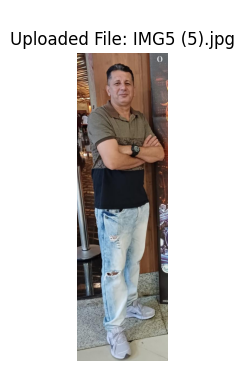


Digite o nome desse funcionário na imagem
Cristiano
✅ Funcionário: 'Cristiano' registrado a imagem 'IMG5 (5).jpg'



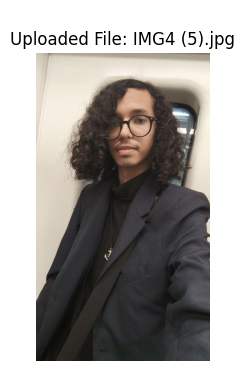


Digite o nome desse funcionário na imagem
Asafe
✅ Funcionário: 'Asafe' registrado a imagem 'IMG4 (5).jpg'

Todos os funcionarios foram registrados com suas respectivas imagens


In [ ]:
# Upload das imagens no Google Colab
# Se você não estiver usando Google Colab, coloque as imagens na mesma pasta do notebook.

try:
    from google.colab import files
    print("Ambiente Google Colab detectado.")
    print("\nEnvie agora a imagem dos funcionários permitidos/imagens de referência.\n")

    uploaded_referencia = files.upload()

    for nome_arquivo in uploaded_referencia.keys():

        # 1. Lê e converte a imagem em RGB
        img = cv2.imread(nome_arquivo)

        #Caso a imagem no caminho esteja corrompida ou com algum problema entra aqui
        if img is None:
          print(f"\033[31mErro ao abrir {nome_arquivo}\033[0m")
          raise ValueError(f"Erro ao abrir {nome_arquivo_teste}. Verifique se o arquivo é uma imagem válida.")
          continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 2. Renderiza a imagem dinamicamente
        plt.figure(figsize=(4, 4)) #  Deixa o tamanho compacto
        plt.imshow(img_rgb)
        plt.axis('off') # Esconde os números das linhas cartesianas do matplot
        plt.title(f"\nUploaded File: {nome_arquivo}")
        plt.show() # Força o Colab a mostrar a figura

        nome_real = input("\nDigite o nome desse funcionário na imagem\n")

        if not nome_real.strip():
          nome_real = f"Unknown_{nome_arquivo}"

          # 4. Save into your typed list
        registro = Imagemfacial(nome_do_funcionario=nome_real, imagem=img)

        banco_funcionarios.append(registro)

        #Exibe a mensagem de funcioonário cadastrado em verde
        print(f"\033[32m✅ Funcionário: '{nome_real}' registrado a imagem '{nome_arquivo}'\033[0m\n")

    print(f"Todos os funcionarios foram registrados com suas respectivas imagens")

except ImportError:
    print("Este ambiente não parece ser o Google Colab.")
    print("Coloque as imagens na mesma pasta deste notebook ou use o caminho completo dos arquivos.")

In [ ]:
extensoes_imagem = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".jfif")

#Listar arquivos:
arquivos = os.listdir()
print("Arquivos disponíveis na pasta atual: ")

for arquivo in arquivos:
  print("-", arquivo)

Arquivos disponíveis na pasta atual: 
- .config
- IMG1 (5).jpg
- IMG6 (2).jpg
- IMG5 (1).jpg
- IMG4 (2).jpg
- IMG1 (2).jpg
- IMG2 (1).jpg
- IMG3.jpg
- IMG4 (1).jpg
- IMG4 (5).jpg
- IMG6.jpg
- IMG6 (1).jpg
- IMG5.jpg
- IMG1 (3).jpg
- IMG_20251209_091447951.jpg
- IMG4.jpg
- IMG2.jpg
- IMG4 (3).jpg
- IMG4 (4).jpg
- IMG5 (3).jpg
- IMG1 (4).jpg
- IMG5 (4).jpg
- IMG5 (5).jpg
- IMG1 (1).jpg
- IMG3 (1).jpg
- IMG1.jpg
- IMG5 (2).jpg
- sample_data


##Pequena validação de quais arquivos estão no sistema no momento

In [ ]:
imagens_disponiveis = [a for a in arquivos if a.lower().endswith(extensoes_imagem)]

print("\nPossíveis imagens encontradas: ")
for i, imagem in enumerate(imagens_disponiveis) :
  print(f"{i}: {imagem}")


Possíveis imagens encontradas: 
0: IMG1 (5).jpg
1: IMG6 (2).jpg
2: IMG5 (1).jpg
3: IMG4 (2).jpg
4: IMG1 (2).jpg
5: IMG2 (1).jpg
6: IMG3.jpg
7: IMG4 (1).jpg
8: IMG4 (5).jpg
9: IMG6.jpg
10: IMG6 (1).jpg
11: IMG5.jpg
12: IMG1 (3).jpg
13: IMG_20251209_091447951.jpg
14: IMG4.jpg
15: IMG2.jpg
16: IMG4 (3).jpg
17: IMG4 (4).jpg
18: IMG5 (3).jpg
19: IMG1 (4).jpg
20: IMG5 (4).jpg
21: IMG5 (5).jpg
22: IMG1 (1).jpg
23: IMG3 (1).jpg
24: IMG1.jpg
25: IMG5 (2).jpg


##Upload da imagem de teste

Envie agora a imagem dos funcionários permitidos/imagens de referência.


Saving IMG1.jpg to IMG1 (6).jpg


Imagem de teste recebida



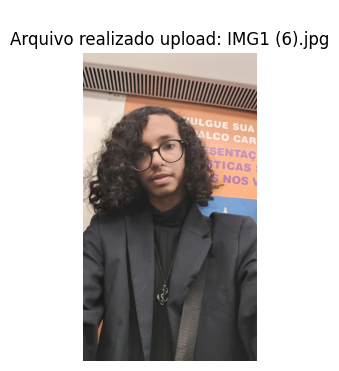

In [ ]:
print("Envie agora a imagem dos funcionários permitidos/imagens de referência.")
uploaded_teste = files.upload()
print("\n")
nome_arquivo_teste = list(uploaded_teste.keys())[0]

if nome_arquivo_teste != None:
  print("\033[32mImagem de teste recebida\033[0m\n")

else:
  print("\033[31mImagem de teste não recebida, tente outra imagem\033[0m\n")
  raise ValueError(f"Erro ao abrir {nome_arquivo_teste}. Verifique se o arquivo é uma imagem válida.")
# 1. Lê e converte a imagem em RGB
imagem_teste = cv2.imread(nome_arquivo_teste)

if imagem_teste is None:
    print(f"\033[31mErro ao abrir {nome_arquivo_teste}\033[0m")

imagem_teste_rgb = cv2.cvtColor(imagem_teste, cv2.COLOR_BGR2RGB)


plt.figure(figsize=(4, 4)) # Deixa o tamanho compacto
plt.imshow(imagem_teste_rgb)
plt.axis('off') # Esconde os números das linhas cartesianas do matplot
plt.title(f"\nArquivo realizado upload: {nome_arquivo_teste}")
plt.show() # Força o Colab a mostrar a figura

##Demonstração das imagens em escala cinza

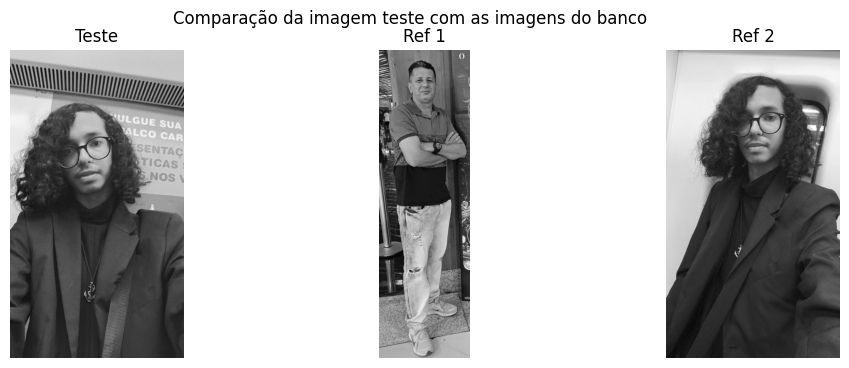

In [ ]:
imagem_teste_cinza = cv2.cvtColor(imagem_teste, cv2.COLOR_BGR2GRAY)

imagens_cinza = []
imagens_cinza.append(imagem_teste_cinza)

if not banco_funcionarios:
    raise ValueError("Nenhum funcionário foi cadastrado. Cadastre ao menos uma imagem de referência.")

for funcionario in banco_funcionarios:
  imagem_referencia_cinza = cv2.cvtColor(funcionario.imagem, cv2.COLOR_BGR2GRAY)

  imagens_cinza.append(imagem_referencia_cinza)

plt.figure(figsize=(4 * len(imagens_cinza), 4))

for i, img in enumerate(imagens_cinza):
    plt.subplot(1, len(imagens_cinza), i + 1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    if i == 0:
        plt.title("Teste")
    else:
        plt.title(f"Ref {i}")

plt.suptitle("Comparação da imagem teste com as imagens do banco")
plt.show()

##Reconhecimento facial com o Deepface e demonstração de identidade do funcionário ao que o usuário corresponde

Comparando imagem do indivíduo de teste com as imagens dos funcionários

Funcionário: Cristiano | Distância: 0.9765 | Verificado/Semelhante: False | Threshold: 0.6800
Funcionário: Asafe | Distância: 0.1676 | Verificado/Semelhante: True | Threshold: 0.6800

Funcionário mais semelhante: Asafe (distância = 0.1676)

Acesso autorizado, bem-vindo Asafe


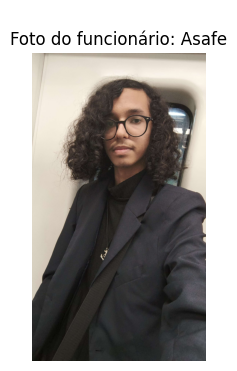

In [ ]:
melhor_funcionario = None
melhor_resultado = None
menor_distancia = float("inf")

print("Comparando imagem do indivíduo de teste com as imagens dos funcionários\n")

for funcionario in banco_funcionarios:

    resultado = DeepFace.verify(
        img1_path=imagem_teste,
        img2_path=funcionario.imagem,
        enforce_detection=True
    )

    print(
      f"Funcionário: {funcionario.nome_do_funcionario} | "
      f"Distância: {resultado['distance']:.4f} | "
      f"Verificado/Semelhante: {resultado['verified']} | "
      f"Threshold: {resultado['threshold']:.4f}"
    )

    if resultado["distance"] < menor_distancia:
        menor_distancia = resultado["distance"]
        melhor_resultado = resultado
        melhor_funcionario = funcionario

print(
    f"\nFuncionário mais semelhante: "
    f"{melhor_funcionario.nome_do_funcionario} "
    f"(distância = {menor_distancia:.4f})"
)
if melhor_resultado["verified"]:

  # Exibe a mensagem em verde quando o acesso é autorizado
    print(f"\n\033[32mAcesso autorizado, bem-vindo {melhor_funcionario.nome_do_funcionario}\033[0m")

    imagem_funcionario_rgb = cv2.cvtColor(melhor_funcionario.imagem, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(4, 4)) # Deixa o tamanho compacto
    plt.imshow(imagem_funcionario_rgb)
    plt.axis('off') # Esconde os números das linhas cartesianas do matplot
    plt.title(f"\nFoto do funcionário: {melhor_funcionario.nome_do_funcionario}")
    plt.show() # Força o Colab a mostrar a figura
else:
  # Exibe a mensagem em vermelho quando o acesso é autorizado
    print("\n\033[31mAcesso negado\033[0m")

##Análise dos resultados, limitações da solução e problemas encontrados

De forma geral, a solução proposta consegue criar uma lista de funcionários com acesso a determinada área, contendo o nome do funcionário que tem acesso e uma imagem para ser comparada com o  usuário, quando ele tentar entrar na área restrita, caso a imagem do indivíduo que deseja entrar na área restrita corresponda a uma das imagens de um dos funcionários no banco de funcionários, o sistema sinalizará o nome do funcionário e lhe concederá o acesso a área restrita, caso o sistema reconheça que a imagem do indíviduo não corresponde a nenhum funcionário, ele indicará que o acesso a área restrita foi negado.

Durante os testes foram realizadas comparações utilizando tanto enforce_detection=False quanto enforce_detection=True. Quando a detecção obrigatória foi desativada, o sistema conseguiu processar um número maior de imagens, porém apresentou casos de falsos positivos, identificando incorretamente imagens que não correspondiam ao mesmo indivíduo. Por outro lado, ao ativar a detecção obrigatória, observou-se uma redução desses falsos positivos, mas o sistema passou a apresentar dificuldades para reconhecer a mesma pessoa em fotografias capturadas sob ângulos diferentes ou em condições distintas das imagens cadastradas.

Um dos problemas encontrados na solução atual é o fato do reconhecimento facial requerer fotos muito parecidas com a presente no banco para identificar a semelhança, pequenas mudanças de iluminação ou estilização de cabelo já são suficientes para o sistema, na forma atual, ter dificuldades em reconhecer o funcionário, o que pode acarretar situações de estresse em meio ao uso do sistema ou até acidentes caso ocorra algo que necessite do acesso e contenção urgente da área restrita.

Para melhorar o sistema e evitar esse problema, seria recomendado o sistema guardar diversas fotos de cada funcionário, organizando-as numa estrutura similar a essa:

     funcionario = {"nome":"funcionario1", "fotos":[img_1, img_2, img_3, img_4 ... , img_n]}

- Onde img_n indica a última imagem, n sendo um número inteiro arbitrário, nesse caso,  decidido como o número suficiente de imagens para o sistema reconhecer consistentemente aquele funcionário em diferentes situações.

##Discussões morais e legais acerca do reconhecimento facial.

A relação entre ciência, tecnologia e ética nem sempre foi simples ao longo da história. Diversos avanços científicos foram obtidos em contextos nos quais direitos humanos, consentimento e segurança dos participantes não receberam a devida atenção. Em resposta a esses problemas, áreas como a Sociologia, a Filosofia e a Bioética passaram a contribuir para uma análise mais crítica das consequências sociais da produção científica e tecnológica. Atualmente, espera-se que novas tecnologias sejam desenvolvidas e utilizadas de forma responsável, respeitando princípios éticos e legais.

No caso específico dos sistemas de reconhecimento facial, essas preocupações tornam-se especialmente relevantes devido à utilização de dados biométricos, ao potencial impacto sobre a privacidade dos indivíduos e aos riscos associados a erros de identificação.

Imagens faciais são dados biométricos sensíveis e seu armazenamento deve ser realizado de forma segura, respeitando a legislação vigente e a privacidade dos indivíduos.

A coleta e utilização de imagens para reconhecimento facial devem ocorrer somente com o conhecimento e a autorização dos envolvidos.

Sistemas de reconhecimento facial podem apresentar vieses decorrentes dos dados utilizados durante seu treinamento. Caso determinados grupos estejam sub-representados ou representados de forma desigual nos conjuntos de dados, a taxa de erros pode variar entre diferentes populações. Em aplicações de segurança pública, pesquisadores e organizações têm apontado casos em que erros de reconhecimento facial resultaram na identificação incorreta de indivíduos inocentes, levantando preocupações sobre discriminação, justiça e responsabilidade no uso dessas tecnologias.

Considerando os desafios relacionados à privacidade, ao consentimento dos indivíduos e à possibilidade de vieses e erros de identificação, é de suma importância que uma tecnologia como o reconhecimento facial seja utilizada de forma ética e responsável. Além disso, seu desenvolvimento e aplicação devem considerar as desigualdades existentes na sociedade, de modo a evitar a reprodução ou ampliação de preconceitos já presentes na realidade. Dessa forma, busca-se utilizar a tecnologia não para reforçar vieses, mas buscar resultados mais precisos e fundamentados em evidências.

Este sistema foi desenvolvido apenas para fins educacionais e não deve ser considerado adequado para utilização em ambientes reais sem testes adicionais, validação técnica e avaliação jurídica.

##Referências

DeepFace Documentation.

OpenCV Documentation.

TensorFlow Documentation.

Material didático da disciplina.

Aula remota 1 e Aula remota 2.